# Q1. How should ClinVar missense variants be split for reliable evaluation on previously unseen genes?

Prepare the **full missense cohort**, using the pilot's filters and split rules without its 5,000-variant cap. [Dependencies](../requirements.txt) · [Implementation](src/q1_full.py) · CPU only.

Use **`data/clinvar_20260706.vcf` (6 July 2026, GRCh38)**, shared with Q0, and the pinned GRCh38 reference. Either notebook downloads the verified July archive if needed.

In [1]:
from src import q1_full
q1_full.settings()

All eligible missense SNVs · ClinVar 2026-07-06, shared with Q0 · no sampling cap
1,024-base contexts · seed 42 · original 70/30 group assignment · CPU only
data/clinvar-train.vcf = training; data/clinvar-test.vcf = validation.


## Filter and preserve groups

Keep missense A/C/G/T substitutions on chromosomes 1–22, X and Y, with **at least two review stars**, usable gene IDs and unambiguous benign/pathogenic labels. Exclude conflicts and inconsistent duplicates; require exact `MC=SO:0001583`. [Exact filtering implementation](src/q0.py).

Preserve the September split for every variant still eligible in July. Fourteen changed component anchors require fixed, label-independent overrides in [q1.py](src/q1.py); new components use the original **seed-42, 70/30 whole-group rule**. The complete July assignment is checksum-pinned before modeling. Genes, loci, source IDs and overlapping 1,024-base windows connect variants across the broader eligible SNV cohort, including nonmissense bridges. Group sizes make the percentages approximate; labels do not determine assignment.

Extract every eligible reference/alternate context. Exclude truncated or non-ACGT windows; fail on a REF mismatch or cross-split identical context, including reverse complements. Preserve every July pilot variant's split and DNA. July eligibility and labels come from the July source; variants absent or ineligible in July are not imported from September.

In [2]:
q1_full.run_checks()
full, sequences = q1_full.prepare()

22 split and sequence integrity tests passed.
10 additional full-dataset integrity tests passed.
Verify ClinVar 2026-07-06, shared with Q0, and inherited group assignments.


Preparing the full Q0 cohort from the verified VCF…


Read 500,000 records


Read 1,000,000 records


Read 1,500,000 records


...

Read 4,000,000 records


5,000 sampled variants retained; 6 leakage check groups passed.


Extract reference/alternate DNA for all 64,815 eligible missense variants.


Leakage checks passed; export and recheck the complete VCF records.


64,815 full-dataset variants; 0 sequence exclusions; 8 audit groups passed.


## Frozen full partitions

**Training** fits preprocessing and models. **Validation** selects settings and compares models. The test-named VCF remains validation, including previously evaluated pilot variants; there is no separate test stage.

[Training VCF](../data/clinvar-train.vcf) · [Validation VCF](../data/clinvar-test.vcf) · [Manifest](results/q1/full/split_manifest.csv) · [Protocol](results/q1/full/protocol.json) · [Sequence exclusions](results/q1/full/sequence_exclusions.csv)

Use these full inputs for new experiments. The completed September Q2/Q8/Q9/Q10 pilot runs, inputs and implementations are archived in [before_shared_july_snapshot](results/archive/before_shared_july_snapshot/). Those scores are excluded from the current July comparison; model evaluations must be rerun on the full July partitions. Clinical annotations supply eligibility and outcomes; predictor inputs contain only DNA.

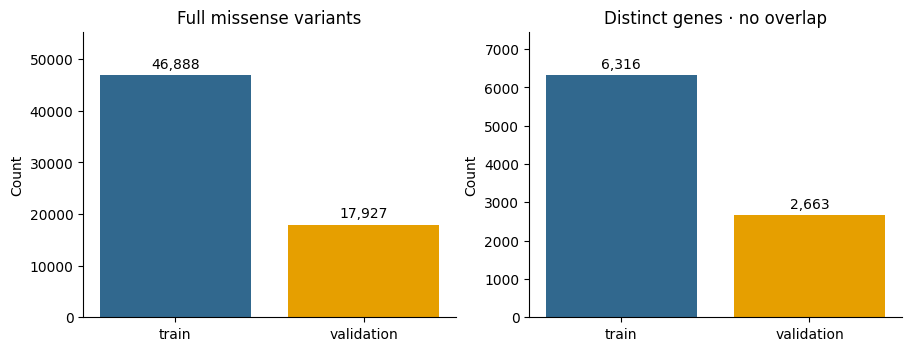

,variants,components,B,P,genes,percent,vcf
split,,,,,,,
train,46888,4888,28715,18173,6316,72.34,clinvar-train.vcf
validation,17927,2032,11404,6523,2663,27.66,clinvar-test.vcf


,stage,retained,removed
0,All records,4439617,0
1,No inconsistent duplicate annotations,4439617,0
2,"Chromosomes 1–22, X, Y",4436444,3173
3,Single A/C/G/T substitution,4131652,304792
4,No germline conflict evidence,3974046,157606
5,Accepted benign/pathogenic label,1476932,2497114
6,At least 2 review stars,341963,1134969
7,At least one usable gene ID,341962,1
8,Collapse consistent duplicate keys,341962,0
9,Exact MC SO:0001583 missense annotation,64815,277147


In [3]:
q1_full.show_splits(full)

In [4]:
q1_full.show_conclusion()

**Conclusion.** The full missense dataset contains **46,888 training (72.34%)** and **17,927 validation (27.66%)** variants. Genes and checked DNA contexts stay within one split, and all July pilot assignments are preserved. Variants shared with the archived September cohort keep their splits. Whole groups make the original 70/30 target approximate. The test-named file remains development validation; homology, shared patients and pretraining overlap are not ruled out.